# Aufgabe 2

In der zweiten Aufgabe, wurde anstelle einer Linse, zwei Glasplanne genommen, die leicht angeschrägt waren. Da ein kleines Stück Kupfer an einem der Enden eingekeilt war. In dieser Aufgabe ist es dass Ziel diese Dicke des Kupferkeils zu ermittel. Die Länge des Plätchens war 2,9cm.

![Skizze des Aufbaus mit dem Kupferkeils, entnommen aus der Versuchserklährung in Theorie im moodle Kurs](./Skizze.png)

## Hier unsere Tabelle mit den Rohdaten

| k | x_k [cm] | Mean |
|---|----------|------|
| 1 | 0.104 | 61 |
| 2 | 0.341 | 79 |
| 3 | 0.575 | 78 |
| 4 | 0.807 | 80 |
| 5 | 1.044 | 96 |
| 6 | 1.268 | 94 |
| 7 | 1.513 | 105 |
| 8 | 1.750 | 125 |
| 9 | 1.975 | 111 |
| 10 | 2.214 | 108 |
| 11 | 2.444 | 123 |
| 12 | 2.683 | 121 |
| 13 | 2.921 | 118 |
| 14 | 3.150 | 119 |

:Tabelle 1: Rohdaten der Positionen x_k der dunklen Interferenzstreifen mit Ordnung k und gemessener mittlerer Intensität

![Bild vom Interferenzmuster aus dem die Rohdaten ermittelt wurden](./O9_Messdaten/Aufgabe_2_besser.jpg)

## Herletiung der GLeichung (4) wird benötigt für den Fit

$$x_k = k \lambda$$

$$2d_k​+ \lambda/2=k \lambda$$

$$2d_k​=kλ−λ/2$$

$$2d_k​=(k−1/2)λ(∗)$$

Die Dicke $d_k​$ der Luftschicht an der Position $x_k$​ ist gegeben durch die Geometrie des Keils

$$\tan \alpha=\frac{x_k}{​d_k}​​=\frac{D}{l}​$$

$$d_k​=x_k \frac{D}{l}​$$

$$2\left(x_k \frac{D}{l} \right​)=(k−1/2)λ$$

Löst man nach $x_k$​ auf, erhält man die Position des k-ten dunklen Interferenzstreifens

$$xk​=\frac{l \lambda}{2D}​(k−\frac{1​}{2})$$

$$x_k = \frac{l \lambda}{2D}k - \frac{l \lambda}{4D}$$

Die Gleichung für die dunklen Interferenzstreifen ist damit hergeleitet, wobei $k$ die Ordnung des dunklen Streifens bezeichnet.

## Diagramm mit Fit 

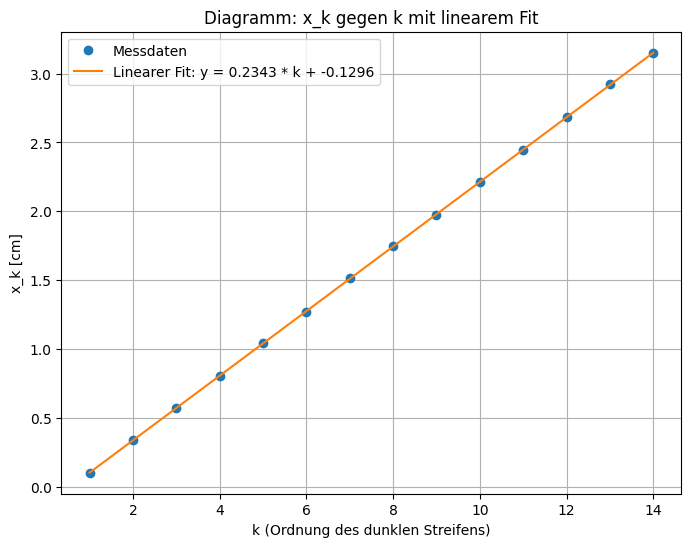

Steigung des Fits: 0.234323 cm/k
Achsenabschnitt des Fits: -0.129637 cm
Berechnete Dicke D des Kupferkeils: 3.92 μm


In [ ]:
# | fig-cap: Diagramm: x_k gegen k mit linearem Fit zur Bestimmung der Dicke $D$
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lade die Daten aus der CSV-Datei
df = pd.read_csv('O9_Messdaten/Aufgabe_2.csv')

# k-Werte: Ordnung der dunklen Streifen, von 1 bis Anzahl der Datenpunkte
k = np.arange(1, len(df) + 1)

# x_k-Werte aus der X-Spalte (Position in cm)
x_k = df['X']

# Linearer Fit: x_k = slope * k + intercept
coeffs = np.polyfit(k, x_k, 1)
slope_cm = coeffs[0]  # Steigung in cm/k
intercept_cm = coeffs[1]  # Achsenabschnitt in cm

# Umrechnung der Steigung in m/k für die Berechnung
slope_m = slope_cm * 0.01  # 1 cm = 0.01 m

# Plot des Diagramms
plt.figure(figsize=(8, 6))
plt.plot(k, x_k, 'o', label='Messdaten')
plt.plot(k, slope_cm * k + intercept_cm, '-', label=f'Linearer Fit: y = {slope_cm:.4f} * k + {intercept_cm:.4f}')
plt.xlabel('k (Ordnung des dunklen Streifens)')
plt.ylabel('x_k [cm]')
plt.title('Diagramm: x_k gegen k mit linearem Fit')
plt.legend()
plt.grid(True)
plt.show()

# Berechnung der Dicke D des Kupferkeils
l = 0.029  # Länge des Plätchens in m (2.9 cm)
lambda_val = 632.8e-9  # Wellenlänge des Lasers in m (HeNe-Laser, typischer Wert)

# Formel: D = l * lambda / (2 * slope_m)
D = l * lambda_val / (2 * slope_m)

print(f'Steigung des Fits: {slope_cm:.6f} cm/k')
print(f'Achsenabschnitt des Fits: {intercept_cm:.6f} cm')
print(f'Berechnete Dicke D des Kupferkeils: {D * 1e6:.2f} μm')



## Fehlerbetrachtung
Die berechnete Dicke D des Kupferkeils beträgt $ D = 3.92 \, \mu m $. Um die Unsicherheit in diesem Wert zu bestimmen, müssen die Unsicherheiten der Messgrößen berücksichtigt werden:

- **Unsicherheit in den Positionen $ x_k $**: Die Messung der Positionen erfolgte manuell aus dem Interferenzmuster. Eine typische Unsicherheit beträgt etwa $ \Delta x_k = 0.01 \, \text{cm} $. Dies führt zu einer Unsicherheit in der Steigung des Fits von $ \Delta m \approx \frac{\Delta x_k}{\sqrt{n}} $, wobei $ n = 14 $ die Anzahl der Datenpunkte ist. Für eine grobe Abschätzung ergibt sich $ \Delta m \approx 0.0027 \, \text{cm/k} $.

- **Unsicherheit in der Länge $ l $**: Die Länge des Plätchens wurde mit $ l = 2.9 \, \text{cm} $ angegeben. Eine Messunsicherheit von $ \Delta l = 0.01 \, \text{cm} = 0.0001 \, \text{m} $ ist realistisch.

- Unsicherheit in der Wellenlänge $ \lambda $: Die Wellenlänge des HeNe-Lasers ist $ \lambda = 632.8 \, \text{nm} $ mit einer Unsicherheit von $ \Delta \lambda = 0.1 \, \text{nm} = 1 \times 10^{-10} \, \text{m} $.

Die relative Unsicherheit in D kann mittels Fehlerfortpflanzung berechnet werden:

$$\frac{\Delta D}{D} = \sqrt{ \left( \frac{\Delta l}{l} \right)^2 + \left( \frac{\Delta \lambda}{\lambda} \right)^2 + \left( \frac{\Delta m}{m} \right)^2 }$$
Mit $ m = 0.234323 \, \text{cm/k} $, $ \Delta m \approx 0.0027 \, \text{cm/k} $, ergibt sich $ \frac{\Delta m}{m} \approx 0.0115 $. Die anderen Terme sind klein, sodass $ \frac{\Delta D}{D} \approx 0.0115 $, also $ \Delta D \approx 0.045 \, \mu m $. Der endgültige Wert ist $ D = (3.92 \pm 0.05) \, \mu m $.

## Diskussion
Der Fit zeigt eine gute lineare Korrelation zwischen $ k $ und $ x_k $, was die Gültigkeit der hergeleiteten Gleichung bestätigt. Abweichungen von der Linearität könnten durch Ungenauigkeiten in der Keilgeometrie oder inhomogene Dicke des Kupfers verursacht werden. Der berechnete Wert von $ D \approx 4 \, \mu m $ liegt im Bereich dünner Folien und ist plausibel für einen Kupferkeil in einem solchen Experiment. Für genauere Messungen könnten automatisierte Verfahren zur Positionsbestimmung verwendet werden, um die Unsicherheit zu reduzieren.